# HBAC Clustering Demo

This notebook demonstrates the **Hierarchical Bias-Aware Clustering (HBAC)** method for detecting shortcuts.

## How HBAC Works

1. **Hierarchical Clustering**: Splits embeddings into clusters based on variance
2. **Purity Analysis**: Checks if clusters align with protected attributes
3. **Dimension Importance**: Identifies which dimensions drive clustering
4. **Linearity Test**: Tests if simple linear classifiers can separate groups

If embeddings form high-purity clusters aligned with sensitive attributes, shortcuts are detected.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from shortcut_detect.clustering import HBACDetector
from shortcut_detect import generate_linear_shortcut, generate_nonlinear_shortcut

print("✅ Imports successful!")

✅ Imports successful!


In [2]:
# Create output directory for saving visualizations
import os
os.makedirs('../output', exist_ok=True)
print("✅ Output directory ready")

✅ Output directory ready


## Example 1: Linear Shortcuts

In [3]:
# Generate data with linear shortcuts
embeddings, labels = generate_linear_shortcut(
    n_samples=1000,
    embedding_dim=50,
    shortcut_dims=3,
    seed=42
)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Class distribution: {np.bincount(labels)}")

Embeddings shape: (1000, 50)
Class distribution: [490 510]


In [4]:
# Create and fit HBAC detector
detector = HBACDetector(
    max_iterations=3,
    min_cluster_size=0.05,
    random_state=42
)

detector.fit(embeddings, labels)

In [5]:
# View text report
print(detector.get_report())

Embedding Shortcut Detection Report

Dataset: 1000 samples, 50 dimensions
Clusters found: 4

SHORTCUT DETECTION RESULT
Shortcuts detected: YES
Confidence: high
Shortcut types: clustering_based, linear_separable

Evidence:
  - High purity clusters: 4
  - Important dimensions ratio: 60.00%
  - Linear separability: 100.00%

CLUSTER ANALYSIS
Cluster 0: size=193, purity=100.00%, dominant_label=1
Cluster 1: size=212, purity=100.00%, dominant_label=1
Cluster 2: size=166, purity=100.00%, dominant_label=0
Cluster 3: size=229, purity=100.00%, dominant_label=0

TOP IMPORTANT DIMENSIONS
dim_1: F-score=2535.92, p-value=0.0000
dim_0: F-score=2516.06, p-value=0.0000
dim_2: F-score=2106.23, p-value=0.0000
dim_30: F-score=45.41, p-value=0.0000
dim_6: F-score=39.57, p-value=0.0000

STATISTICAL TESTS
Most deviant cluster: 0
Z-score: 15.75
P-value: 0.0000
Significant: True


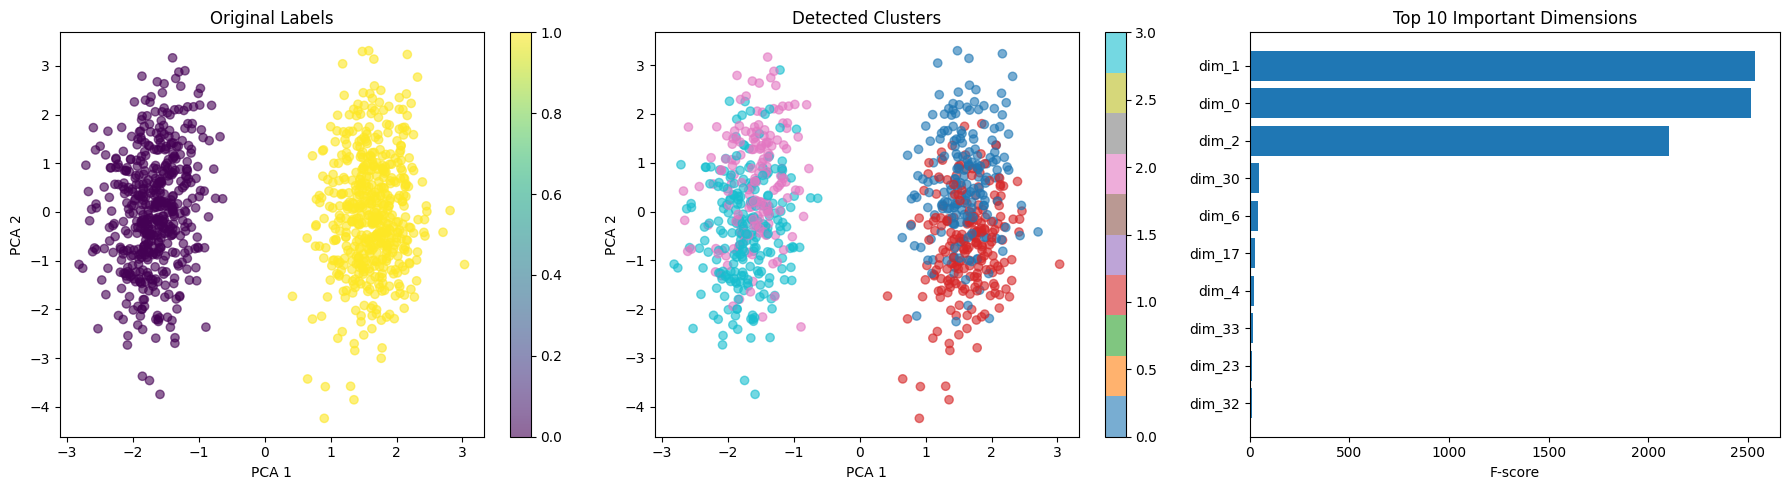

In [6]:
# Visualize results
detector.visualize(method='pca', save_path='../output/hbac_linear_pca.png')

## Example 2: Nonlinear Shortcuts

In [7]:
# Generate data with nonlinear (radial) shortcuts
embeddings_nl, labels_nl = generate_nonlinear_shortcut(
    n_samples=800,
    embedding_dim=40,
    seed=100
)

detector_nl = HBACDetector(max_iterations=4)
detector_nl.fit(embeddings_nl, labels_nl)

print(detector_nl.get_report())

Embedding Shortcut Detection Report

Dataset: 800 samples, 40 dimensions
Clusters found: 5

SHORTCUT DETECTION RESULT
Shortcuts detected: NO
Confidence: low

Evidence:
  - High purity clusters: 0
  - Important dimensions ratio: 95.00%
  - Linear separability: 45.62%

CLUSTER ANALYSIS
Cluster 0: size=313, purity=50.80%, dominant_label=0
Cluster 1: size=75, purity=52.00%, dominant_label=0
Cluster 2: size=85, purity=51.76%, dominant_label=1
Cluster 3: size=73, purity=52.05%, dominant_label=1
Cluster 4: size=94, purity=51.06%, dominant_label=0

TOP IMPORTANT DIMENSIONS
dim_30: F-score=32.79, p-value=0.0000
dim_14: F-score=25.10, p-value=0.0000
dim_20: F-score=24.35, p-value=0.0000
dim_29: F-score=23.04, p-value=0.0000
dim_24: F-score=15.75, p-value=0.0000

STATISTICAL TESTS
Most deviant cluster: 3
Z-score: 0.43
P-value: 0.6674
Significant: False


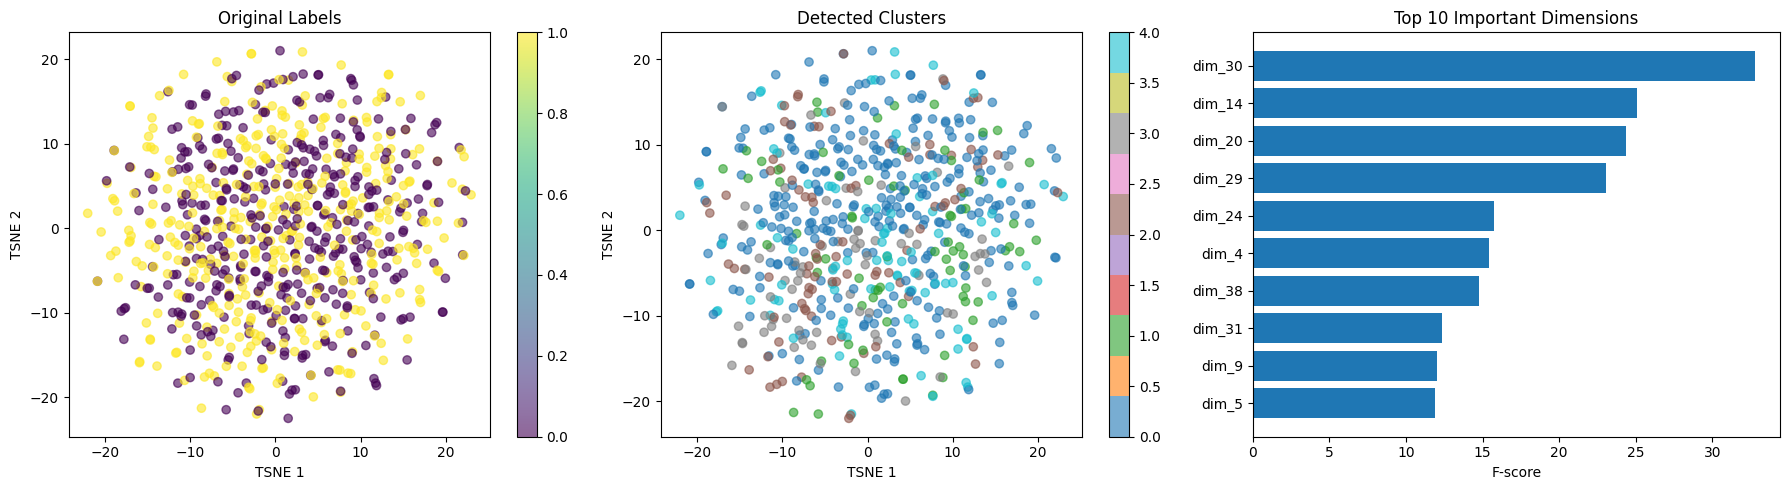

In [8]:
# Visualize with t-SNE
detector_nl.visualize(method='tsne', save_path='../output/hbac_nonlinear_tsne.png')

## Understanding HBAC Results

### Key Metrics:

1. **Cluster Purity**: Higher purity (>80%) means clusters align with labels
2. **Important Dimensions**: F-scores show which dimensions drive separation
3. **Linear Test Accuracy**: High accuracy (>85%) indicates simple shortcuts

### Interpretation:

- **High purity + High linearity** → Strong linear shortcuts
- **High purity + Low linearity** → Nonlinear shortcuts
- **Low purity** → No clear shortcuts (good!)